# Deep Graph Anomaly Detection — Demo

This notebook demonstrates the full pipeline for unsupervised graph anomaly detection
on the PROTEINS dataset, comparing two approaches:

- **GAE** (Graph Autoencoder) — reconstruction-based baseline
- **SimCLR** — contrastive learning approach

Import the trained models and visualize results.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch_geometric.loader import DataLoader as PyGDataLoader
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

from src.dataset import load_dataset, get_dataset_stats
from src.models import GAE, SimCLRModel
from src.augmentations import augment

DEVICE = torch.device(
    #'cuda' if torch.cuda.is_available()
    #else 'mps' if torch.backends.mps.is_available()
    #else 
    'cpu'
)
HIDDEN_DIM = 64
PROJ_DIM = 128
BATCH_SIZE = 32
VAL_SIZE = 0.15
TEST_SIZE = 0.15

print('Device:', DEVICE)

Device: cpu


## 1. Dataset

In [21]:
dataset = load_dataset('src/datasets/', 'PROTEINS')
stats = get_dataset_stats(dataset)

print('Dataset statistics:')
for k, v in stats.items():
    print(f'  {k}: {v:.2f}' if isinstance(v, float) else f'  {k}: {v}')

y = np.array([g.y.item() for g in dataset])
unique, counts = np.unique(y, return_counts=True)
print(f'\nClass distribution: {dict(zip(unique.tolist(), counts.tolist()))}')

1113, 3, 2
Dataset statistics:
  num_graphs: 1113
  node_features: 3
  num_classes: 2
  mean_nodes: 39.06
  mean_edges: 145.63

Class distribution: {0: 663, 1: 450}


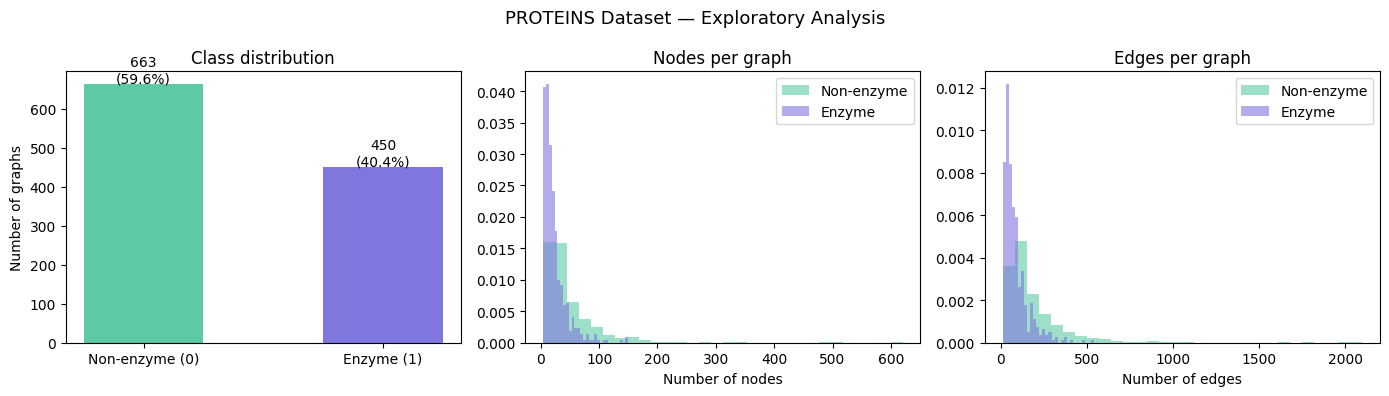

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# class distribution
axes[0].bar(['Non-enzyme (0)', 'Enzyme (1)'], counts, color=['#5DCAA5', '#7F77DD'], width=0.5)
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Number of graphs')
for i, (_, c) in enumerate(zip(unique, counts)):
    axes[0].text(i, c + 5, f'{c}\n({100*c/len(y):.1f}%)', ha='center', fontsize=10)

# nodes per graph
nodes = [g.num_nodes for g in dataset]
axes[1].hist([n for n, l in zip(nodes, y) if l == 0], bins=30, alpha=0.6, color='#5DCAA5', label='Non-enzyme', density=True)
axes[1].hist([n for n, l in zip(nodes, y) if l == 1], bins=30, alpha=0.6, color='#7F77DD', label='Enzyme', density=True)
axes[1].set_title('Nodes per graph')
axes[1].set_xlabel('Number of nodes')
axes[1].legend()

# edges per graph
edges = [g.num_edges for g in dataset]
axes[2].hist([e for e, l in zip(edges, y) if l == 0], bins=30, alpha=0.6, color='#5DCAA5', label='Non-enzyme', density=True)
axes[2].hist([e for e, l in zip(edges, y) if l == 1], bins=30, alpha=0.6, color='#7F77DD', label='Enzyme', density=True)
axes[2].set_title('Edges per graph')
axes[2].set_xlabel('Number of edges')
axes[2].legend()

plt.suptitle('PROTEINS Dataset — Exploratory Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('results/figures/eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Load trained models

In [23]:
train_idx = np.load('results/train_idx.npy')
test_idx = np.load('results/test_idx.npy')

train_graphs = [dataset[i] for i in train_idx]
test_graphs  = [dataset[i] for i in test_idx]

test_loader = PyGDataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

in_channels = dataset[0].x.shape[1]

gae_model = GAE(in_channels, HIDDEN_DIM).to(DEVICE)
gae_model.load_state_dict(torch.load('models/best_gae.pt', map_location=DEVICE))
gae_model.eval()

clr_model = SimCLRModel(in_channels, HIDDEN_DIM, PROJ_DIM).to(DEVICE)
clr_model.load_state_dict(torch.load('models/best_CLR.pt', map_location=DEVICE))
clr_model.eval()

print('Models loaded successfully')

Models loaded successfully


## 3. Anomaly scores

In [24]:
from torch_geometric.utils import to_dense_adj
import torch.nn.functional as F

# GAE scores
@torch.no_grad()
def get_gae_scores(model, loader):
    scores, labels = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        z = model(batch.x, batch.edge_index, batch.batch)
        A_hats = model.decode(z, batch.batch)
        A = to_dense_adj(batch.edge_index, batch.batch)
        for i in range(len(A_hats)):
            n = A_hats[i].shape[0]
            score = F.mse_loss(A_hats[i], A[i][:n, :n]).item()
            scores.append(score)
            labels.append(batch.y[i].item())
    return np.array(scores), np.array(labels)

# SimCLR scores
@torch.no_grad()
def get_clr_scores(model, train_graphs, test_loader):
    train_loader = PyGDataLoader(
        [augment(g, 0.1, 0.1) for g in train_graphs],
        batch_size=BATCH_SIZE, shuffle=False
    )
    # compute centroid
    all_z = []
    for batch in train_loader:
        batch = batch.to(DEVICE)
        z = model.encoder(batch.x, batch.edge_index, batch.batch)
        all_z.append(z)
    center = torch.cat(all_z, dim=0).mean(dim=0)

    # compute scores
    scores, labels = [], []
    for batch in test_loader:
        batch = batch.to(DEVICE)
        z = model.encoder(batch.x, batch.edge_index, batch.batch)
        dists = torch.norm(z - center, dim=1).cpu().numpy()
        scores.extend(dists)
        labels.extend(batch.y.cpu().numpy())
    return np.array(scores), np.array(labels)

gae_scores, gae_labels = get_gae_scores(gae_model, test_loader)
clr_scores, clr_labels = get_clr_scores(clr_model, train_graphs, test_loader)

gae_auc = roc_auc_score(gae_labels, gae_scores)
clr_auc = roc_auc_score(clr_labels, clr_scores)

print(f'GAE  AUC: {gae_auc:.4f}')
print(f'SimCLR AUC: {clr_auc:.4f}')

GAE  AUC: 0.4336
SimCLR AUC: 0.7094


## 4. Results

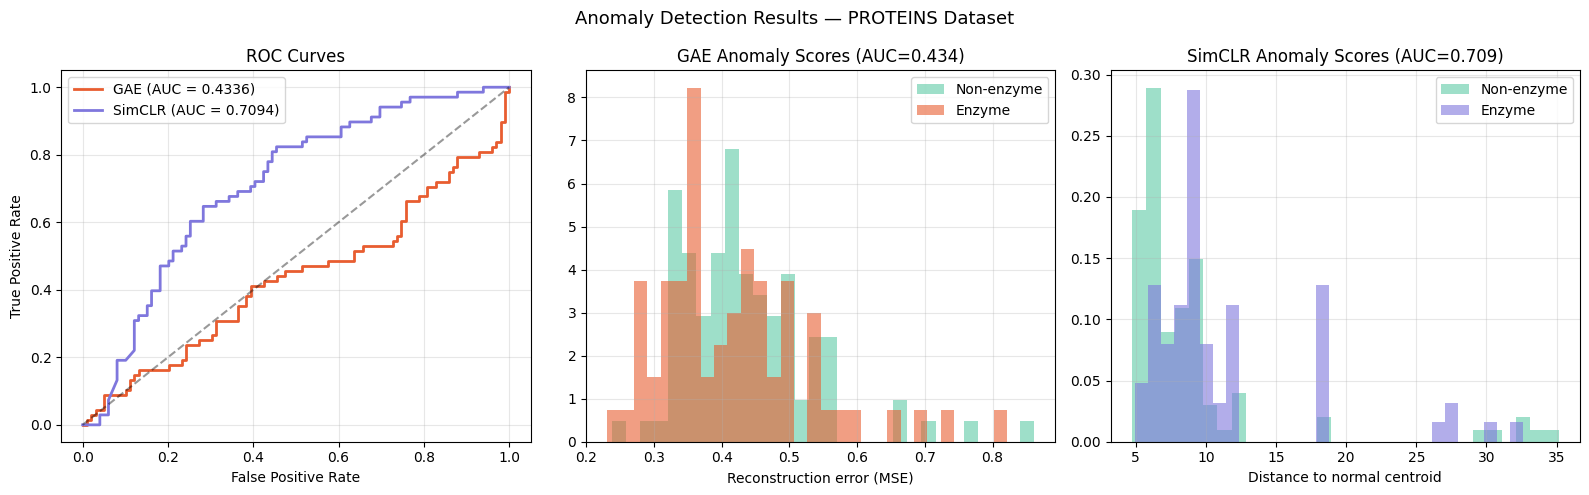

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC curves
for scores, labels, name, color, auc in [
    (gae_scores, gae_labels, 'GAE', '#E85D30', gae_auc),
    (clr_scores, clr_labels, 'SimCLR', '#7F77DD', clr_auc),
]:
    fpr, tpr, _ = roc_curve(labels, scores)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

# GAE score distribution
axes[1].hist(gae_scores[gae_labels==0], bins=30, alpha=0.6, color='#5DCAA5', label='Non-enzyme', density=True)
axes[1].hist(gae_scores[gae_labels==1], bins=30, alpha=0.6, color='#E85D30', label='Enzyme', density=True)
axes[1].set_title(f'GAE Anomaly Scores (AUC={gae_auc:.3f})')
axes[1].set_xlabel('Reconstruction error (MSE)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# SimCLR score distribution
axes[2].hist(clr_scores[clr_labels==0], bins=30, alpha=0.6, color='#5DCAA5', label='Non-enzyme', density=True)
axes[2].hist(clr_scores[clr_labels==1], bins=30, alpha=0.6, color='#7F77DD', label='Enzyme', density=True)
axes[2].set_title(f'SimCLR Anomaly Scores (AUC={clr_auc:.3f})')
axes[2].set_xlabel('Distance to normal centroid')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Anomaly Detection Results — PROTEINS Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('results/figures/results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary

| Model | Approach | Test AUC |
|-------|----------|----------|
| GAE | Reconstruction-based | 0.434 |
| **SimCLR** | **Contrastive learning** | **0.709** |

**SimCLR outperforms GAE by +0.29 AUC** on the PROTEINS dataset.

The contrastive objective learns more discriminative representations of normal graphs
compared to adjacency reconstruction. Anomalous graphs (enzymes) are pushed further
from the learned normal distribution centroid, making them easier to detect.

This validates the pipeline proposed for the ML4SCI GENIE GSoC project, where the
same approach will be applied to particle physics data for new physics searches.